# Modelo Red Neuronal con datos de viajes por minuto entre estaciones

In [1]:
version = "7_1"

In [2]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [3]:
with open("../../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [4]:
df_model = df_data.drop(columns=[
    "ride_id",
    "ended_at",
    "time_hms_ms",
    "member_casual",
    "start_station_id",
    "end_station_id",
    "month",
    "day",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "hour_float"
])

In [ ]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [6]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [7]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos
count,8.449988e+06,8.449988e+06,8449988,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06
mean,1.450911e+03,1.451876e+03,2023-03-16 04:31:05.336045568,1.125538e+00,2.022699e+03,-3.432624e-02,-2.494609e-03,1.900528e-02,4.481394e-04,4.963043e-03,-3.224312e-01,-2.771848e-01,-8.766727e-02,-2.566817e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.514941e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.357000e+03,1.358000e+03,2022-08-08 10:30:00,1.000000e+00,2.022000e+03,-7.877370e-01,-6.945892e-01,-7.485968e-01,-9.970427e-02,-5.614845e-02,-9.360595e-01,-7.995536e-01,-8.660254e-01,-8.660254e-01
50%,1.447000e+03,1.450000e+03,2023-04-13 21:30:00,1.000000e+00,2.023000e+03,1.705535e-01,-8.383434e-02,2.920097e-02,-9.970427e-02,-5.614845e-02,-5.953488e-01,-3.916012e-01,-2.449294e-16,-5.000000e-01
75%,1.565000e+03,1.565000e+03,2023-09-13 09:00:00,1.000000e+00,2.023000e+03,7.535012e-01,6.207274e-01,8.069446e-01,-9.970427e-02,-5.614845e-02,2.312527e-01,1.124084e-01,5.000000e-01,5.000000e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,1.900000e+01,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,2.203498e+02,2.189548e+02,NaN,4.291263e-01,6.872373e-01,1.008835e+00,1.001293e+00,9.986553e-01,9.960138e-01,1.044952e+00,6.844901e-01,5.921825e-01,7.087186e-01,6.512657e-01


In [8]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
10000,5,1371,2024-05-16 13:30:00,1,2024,-0.005158,-1.169974,0.235834,-0.099704,-0.056148,-0.356194,-0.934412,0.5,-0.866025,False,True,False,False
10001,5,1371,2024-05-19 00:30:00,1,2024,1.153503,-0.217690,-1.105367,-0.099704,-0.056148,0.182164,0.983268,0.5,-0.866025,False,False,True,False
10002,5,1371,2024-05-19 21:00:00,1,2024,0.687351,0.115036,-1.543506,-0.099704,-0.056148,-0.720248,0.693716,0.5,-0.866025,False,False,True,False
10003,5,1371,2024-05-23 07:30:00,1,2024,-0.048741,-0.802828,-0.263529,-0.099704,-0.056148,0.945471,-0.325706,0.5,-0.866025,False,True,False,False
10004,5,1371,2024-05-25 09:30:00,1,2024,-0.075949,-0.447805,1.096805,-0.099704,-0.056148,0.561722,-0.827326,0.5,-0.866025,False,False,True,False
10005,5,1371,2024-05-25 14:00:00,1,2024,0.032741,-0.229163,-0.185085,-0.099704,-0.056148,-0.509730,-0.860335,0.5,-0.866025,False,False,True,False
10006,5,1371,2024-05-30 19:30:00,1,2024,0.397944,-0.076185,-1.916593,-0.099704,-0.056148,-0.900698,0.434445,0.5,-0.866025,False,True,False,False
10007,5,1372,2022-01-08 11:00:00,1,2022,-2.589146,0.619862,0.178436,-0.099704,0.472357,0.278851,-0.960334,0.5,0.866025,False,False,True,False
10008,5,1372,2022-01-14 12:30:00,1,2022,-1.607230,1.537726,0.675886,-0.099704,-0.056148,-0.141909,-0.989880,0.5,0.866025,False,True,False,False
10009,5,1372,2022-01-15 14:30:00,1,2022,-2.237724,1.159107,0.540044,-0.099704,-0.056148,-0.574470,-0.818526,0.5,0.866025,False,False,True,False


In [9]:
df_agg['n_viajes'].value_counts(normalize=False)


n_viajes
1     7597015
2      711947
3       97226
4       30005
5        8521
6        3108
7        1258
8         474
9         233
10         92
11         57
12         26
13         14
14          6
16          3
19          1
18          1
17          1
Name: count, dtype: int64

Se unen cantidad de viajes muy poco frecuentes

n_viajes
1     7597015
2      711947
3       97226
4       30005
5        8521
6        3108
7        1258
8         474
9         233
10        201
Name: count, dtype: int64


## Se ordena por tiempo el dataset

In [13]:
df_agg = df_agg.sort_values("started_minute")

## Obtención de datos

In [14]:
x_context = df_agg.drop(columns=[
    "n_viajes",
    "started_minute",
    "start_station_idx",
    "end_station_idx"
])

x_start = df_agg[[
    "start_station_idx",
]]

x_end = df_agg[[
    "end_station_idx",
]]

y = df_agg["n_viajes"]

In [15]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
1155803,2022,-0.976737,-1.032294,1.383795,-0.099704,-0.056148,0.063661,0.997972,0.5,0.866025,False,False,False,True
1139349,2022,-0.976737,-1.032294,1.383795,-0.099704,-0.056148,0.028867,0.999583,0.5,0.866025,False,False,False,True
6357102,2022,-0.976737,-1.032294,1.383795,-0.099704,-0.056148,0.004363,0.999990,0.5,0.866025,False,False,False,True
1580526,2022,-0.976737,-1.032294,1.383795,-0.099704,-0.056148,0.040204,0.999191,0.5,0.866025,False,False,False,True
7960464,2022,-0.976737,-1.032294,1.383795,-0.099704,-0.056148,0.052409,0.998626,0.5,0.866025,False,False,False,True


In [32]:
x_start.head()

,start_station_idx
0,0
1,0
2,0
3,0
4,0


In [33]:
x_end.head()

,end_station_idx
0,0
1,0
2,0
3,0
4,0


In [34]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: n_viajes, dtype: int64

## Compruebo que de verdad hay viajes de ida y vuelta con el mismo id

In [35]:
df_check = df_data["start_station_idx"] == df_data["end_station_idx"]

In [36]:
# Contar numero de True
n_same_station = df_check.sum()
print(f"Número de viajes de ida y vuelta con la misma estación de inicio y fin: {n_same_station}")

Número de viajes de ida y vuelta con la misma estación de inicio y fin: 615646


## Se continua diviendo los datos

In [16]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [ ]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_tain, x_end_test, y_train, y_test = train_test_split(
    x_context, 
    x_start, 
    x_end,
    y, 
    test_size=0.2, 
    random_state=42
)

# ---------- split del train en train/val
x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = train_test_split(
    x_ctx_train,
    x_start_train,
    x_end_tain,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True # No se puede estratificar porque hay estaciones con muy pocos datos
)

## Se continua con la creación del modelo

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim)(input_start)
embed_end = layers.Embedding(num_stations, embed_dim)(input_end)

# Flatten embeddings
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

print(f"Num stations: {num_stations}")
print(f"Num features: {num_features}")
print(f"Embeddings dimension: { embed_dim}")

# Concatenar todo
x = layers.Concatenate()([flat_start, flat_end, input_context])
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='linear')(x)

model = Model(inputs=[input_start, input_end, input_context], outputs=output)
optimizer = Adam(learning_rate=1e-3)  # o prueba 1e-4, 5e-4
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model.summary()

Num stations: 1912
Num features: 14
Embeddings dimension: 44


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 44)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 44)        │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 102)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     13,184 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 191,809 (749.25 KB)

 Trainable params: 191,809 (749.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Entrenamiento
history = model.fit(
    {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
    y_train,
    validation_data=(
        {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
        y_val
    ),    
    batch_size=256,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.6069 - mae: 0.2930 - val_loss: 0.0537 - val_mae: 0.0823
Epoch 2/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0583 - mae: 0.1072 - val_loss: 0.0536 - val_mae: 0.0834
Epoch 3/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.0542 - mae: 0.0931 - val_loss: 0.0535 - val_mae: 0.0952
Epoch 4/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0539 - mae: 0.0898 - val_loss: 0.0536 - val_mae: 0.0808
Epoch 5/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0537 - mae: 0.0894 - val_loss: 0.0535 - val_mae: 0.0978
Epoch 6/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0537 - mae: 0.0894 - val_loss: 0.0534 - val_mae: 0.0911
Epoch 7/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.0537 - mae: 0.0894 - val_loss: 0.0534 - val_mae: 0.0855
Epoch 8/20
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0536 - mae: 0.0894 - val_loss: 0.0534 - val_mae: 0.0886
Epoch 9/20
22684

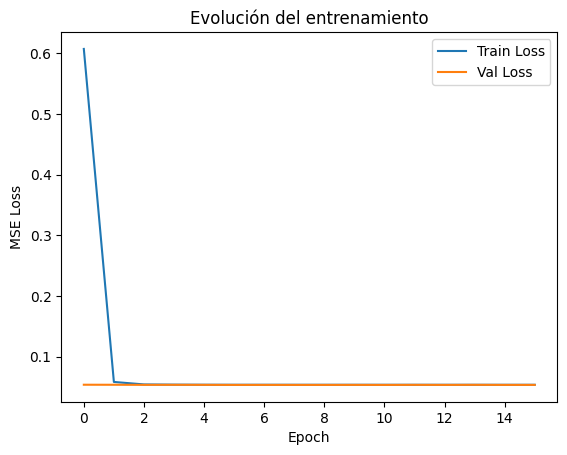

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Evolución del entrenamiento')
plt.show()

In [66]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

## Evaluación del modelo

In [42]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': x_start_test, 'end_station': x_end_test, 'context': x_ctx_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

56709/56709 - 40s - 697us/step - loss: 0.0538 - mae: 0.0890
Test metrics (loss, accuracy): [0.053846754133701324, 0.0889798253774643]


## Predicción del modelo

In [46]:
# Buscar viajes con n_viajes diferente de 1
df_test = df_agg[df_agg["n_viajes"] > 1]

In [47]:
df_test.head()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
26,0,0,2022-06-27 15:50:00,2,2022,0.683841,1.295271,-1.540257,-0.099704,-0.056148,-0.843118,-0.537729,1.224647e-16,-1.000000e+00,False,True,False,False
56,0,0,2023-05-28 12:43:00,2,2023,-0.043056,-1.307653,-0.452943,-0.099704,-0.056148,-0.185452,-0.982653,5.000000e-01,-8.660254e-01,True,False,True,False
66,0,0,2023-07-17 19:21:00,2,2023,0.914742,0.619862,-1.222077,-0.099704,-0.056148,-0.937864,0.347004,-5.000000e-01,-8.660254e-01,False,True,False,False
67,0,0,2023-07-17 19:22:00,2,2023,0.914742,0.619862,-1.224947,-0.099704,-0.056148,-0.937307,0.348504,-5.000000e-01,-8.660254e-01,False,True,False,False
81,0,0,2023-09-15 18:34:00,2,2023,0.667713,-1.119491,-1.084321,-0.099704,-0.056148,-0.989091,0.147306,-1.000000e+00,-1.836970e-16,True,True,False,False


In [61]:
df_test.columns

Index(['start_station_idx', 'end_station_idx', 'started_minute', 'n_viajes',
       'year', 'temp_std', 'wind_std', 'rel_humidity_std', 'precipitation_std',
       'snow_depth_std', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'event', 'normal_day', 'weekend_day', 'holiday_day'],
      dtype='object')

In [69]:
import pandas as pd
import numpy as np

# Lista para ir guardando resultados
results = []

cont = 100
# Recorrer df_test fila a fila
for row in df_test.itertuples():
    # Preparar inputs
    start_idx = np.array([[row.start_station_idx]])
    end_idx   = np.array([[row.end_station_idx]])
    context_values = np.array(row[5:]).reshape(1, -1)  # 1 fila, 14 features
    n_viajes_expected = row.n_viajes

    # Predecir
    prediction = model.predict(
        {'start_station': start_idx,
         'end_station': end_idx,
         'context': context_values},
        verbose=0
    )

    # Guardar resultados
    results.append({
        "start_station_idx": row.start_station_idx,
        "end_station_idx": row.end_station_idx,
        "n_viajes_real": n_viajes_expected,
        "n_viajes_pred": prediction[0][0]
    })
    
    cont -= 1
    
    if cont == 0:
        break

# Crear nuevo DataFrame con resultados
df_results = pd.DataFrame(results)

# Opcional: añadir columna de error absoluto
df_results["error_abs"] = np.abs(df_results["n_viajes_real"] - df_results["n_viajes_pred"])

# Ver primeras filas
print(df_results.head(100))

# Estadísticas de error 
print("MAE:", df_results["error_abs"].mean())
print("Número de predicciones exactas:", (df_results["error_abs"]==0).sum())


    start_station_idx  end_station_idx  n_viajes_real  n_viajes_pred  \
0                   0                0              2       1.023970   
1                   0                0              2       1.047088   
2                   0                0              2       1.029958   
3                   0                0              2       1.029971   
4                   0                0              2       1.026123   
5                   1                1              2       1.049264   
6                   1                1              2       1.011859   
7                   1                1              2       1.047482   
8                   1              887              2       1.067168   
9                   1             1272              2       1.011859   
10                  1             1274              2       1.036900   
11                  2                2              2       1.068520   
12                  2                2              2       1.09